In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

# Using PCA for parsimony

## Create data

In [14]:
from sklearn import datasets

n_feat = 50

X, y = datasets.make_blobs(
    n_samples=1000,
    n_features=n_feat,
    centers=10,
    cluster_std=15.0,
    random_state=0
)

## Train / test split

In [15]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

## PCA

In [16]:
from sklearn.decomposition import PCA

# Apply PCA on training data
pca = PCA(n_components=n_feat)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

## Modeling

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Initialize models
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
lr = LogisticRegression(max_iter=1000)

# Store accuracy scores
rf_train_acc, rf_test_acc = [], []
lr_train_acc, lr_test_acc = [], []

# Loop over number of PCA components
for k in tqdm(range(1, n_feat + 1), ncols=50):
    X_train_k = X_train_pca[:, :k]
    X_test_k = X_test_pca[:, :k]

    # Random Forest
    rf.fit(X_train_k, y_train)
    rf_train_acc.append(accuracy_score(y_train, rf.predict(X_train_k)))
    rf_test_acc.append(accuracy_score(y_test, rf.predict(X_test_k)))

    # Logistic Regression
    lr.fit(X_train_k, y_train)
    lr_train_acc.append(accuracy_score(y_train, lr.predict(X_train_k)))
    lr_test_acc.append(accuracy_score(y_test, lr.predict(X_test_k)))

 64%|████████▎    | 32/50 [00:08<00:07,  2.43it/s]c:\Users\Graham West\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
 68%|████████▊    | 34/50 [00:09<00:07,  2.08it/s]c:\Users\Graham West\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alterna

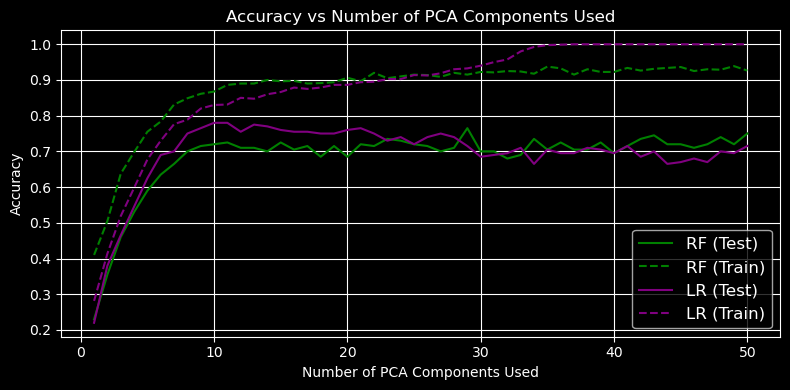

In [18]:
# Plotting
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(8, 4))

# Random Forest (green)
plt.plot(x, rf_test_acc, color='green', label='RF (Test)')
plt.plot(x, rf_train_acc, '--', color='green', label='RF (Train)')

# Logistic Regression (purple)
plt.plot(x, lr_test_acc, color='purple', label='LR (Test)')
plt.plot(x, lr_train_acc, '--', color='purple', label='LR (Train)')

plt.xlabel("Number of PCA Components Used")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of PCA Components Used")
plt.legend(loc='lower right', fontsize='large')
plt.grid(True)
plt.tight_layout()
plt.show()